<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 3.1}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumna:} & Marisol Luna Méndez \\[6pt]
\textbf{Fecha de realización:} & 25/02/2026
\end{array}

</center>

# Fundamentos de Naive Bayes

**Objetivo**:
Implementar el algoritmo Naive Bayes para clasificar objetos basados en características continuas/discretas, comparando la lógica manual con la implementación de scikit-learn.

# Introducción Teórica
Naive Bayes se basa en la suposición de que las características (peso y textura) son independientes entre sí dada la clase. Aunque en la realidad esto rara vez se cumple, el algoritmo es extremadamente eficiente y sirve como "baseline" para modelos más complejos.

**Actividades de los alumnos**:

- **Cálculo manual**: Antes de programar, calculen en papel la probabilidad para una fruta de 180g y textura 6 usando los promedios de la tabla.

- **Análisis de la Gaussiana**: ¿Qué sucede si la desviación estándar de una característica es 0?  

- **Comparativa**: Modifique los datos para que una Toronja sea muy ligera. ¿Cómo reacciona el modelo? ¿Es más sensible al peso o a la textura?

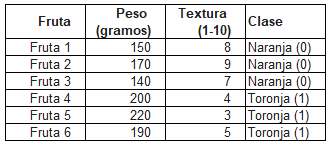


Usaremos la fórmula de la desviación estándar poblacional:

σ=
N
∑(x
i
​
 −μ)
2


##1. Clase Naranja (Clase 0)
Ya sabemos que sus promedios son μ
peso
​
 =153.33 y μ
textura
​
 =8.

###Para el Peso:

(150−153.33)
2
 =11.08

(170−153.33)
2
 =277.88

(140−153.33)
2
 =177.68

Suma =466.64 / 3=155.54

σ peso_naranja  =155.54  ≈12.47

##Para la Textura:

(8−8)
2
 =0

(9−8)
2
 =1

(7−8)
2
 =1

Suma =2 / 3=0.66

σ textura_naranja  = 0.66 ≈0.81

2. Clase Toronja (Clase 1)

Sus promedios son
 $\mu_{peso} = 203.33$ y $\mu_{textura} = 4$.

 Para el Peso:

 $(200 - 203.33)^2 = 11.08$

 $(220 - 203.33)^2 = 277.88$

 $(190 - 203.33)^2 = 177.68$

 $Suma $= 466.64$ / $3 = 155.54$

 $\sigma_{peso\_toronja} = \sqrt{155.54} \approx \mathbf{12.47}$

 Para la Textura:

 $(4 - 4)^2 = 0$

 $(3 - 4)^2 = 1$

 $(5 - 4)^2 = 1$

 Suma $= 2$ / $3 = 0.66$

 $\sigma_{textura\_toronja} = \sqrt{0.66} \approx \mathbf{0.81}$

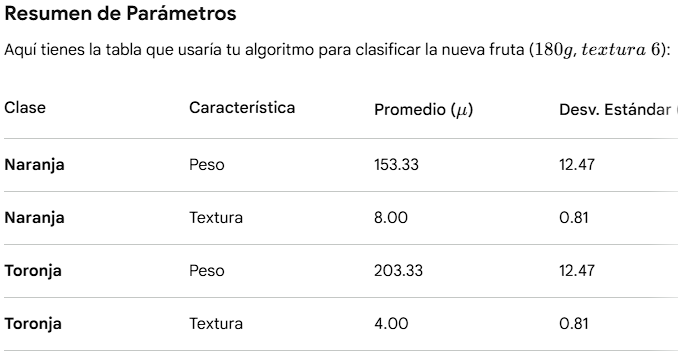

Nota que la desviación estándar de la textura (0.81) es mucho más pequeña que la del peso (12.47). Esto significa que el modelo es mucho más "estricto" con la textura. Como la fruta de prueba tiene textura 6 (está a más de 2 desviaciones estándar de ambas clases), este valor tendrá un peso enorme en la decisión final.

#Estableciendo variables aleatorias

In [ ]:
import numpy as np

# Datos: [Peso, Textura]
X = np.array([
    [150, 8], [170, 9], [140, 7], [130, 8], # Clase 0: Naranja
    [200, 4], [220, 3], [190, 5], [210, 2]  # Clase 1: Toronja
])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])


# 1. Implementación con Bibliotecas (sklearn)

Esta versión muestra cómo el mismo problema se resuelve con estándares industriales.

[Sklearn](https://scikit-learn.org/stable/user_guide.html)

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Crear y entrenar el modelo
clf = GaussianNB()
clf.fit(X, y)

# Predicción
nueva_fruta = [[180, 6]]
prediccion = clf.predict(nueva_fruta)
print(f"Predicción Scikit-Learn: {'Naranja' if prediccion[0] == 0 else 'Toronja'}")

Predicción Scikit-Learn: Toronja


# 2 Implementación "Desde Cero" (Numpy)

Usaremos un dataset pequeño donde clasificamos si una fruta es Naranja o Toronja basándonos en dos características: Peso (g) y Textura (1-10).El AlgoritmoLos alumnos deben calcular la probabilidad de que una fruta sea una Naranja ($N$) dado que pesa 150g ($P$) y tiene textura 8 ($T$):

$$P(N | P, T) \propto P(N) \cdot P(P | N) \cdot P(T | N)$$

In [ ]:
def entrenar_naive_bayes(X, y):
    resumen = {}
    for clase in np.unique(y):
        datos_clase = X[y == clase]
        resumen[clase] = {
            'prior': len(datos_clase) / len(X),
            'promedios': datos_clase.mean(axis=0),
             'desviaciones': datos_clase.std(axis=0)
        }
    return resumen

In [ ]:
import numpy as np
import logging

# Configuración básica del logger
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

def entrenar_naive_bayes(X, y):
    """
    Entrena un modelo Naive Bayes Gaussiano calculando los parámetros estadísticos.

    Calcula la probabilidad a priori, la media y la desviación estándar para
    cada característica, agrupadas por las clases presentes en el vector de etiquetas.

    Args:
        X (numpy.ndarray): Matriz de características de forma (n_samples, n_features).
        y (numpy.ndarray): Vector de etiquetas de forma (n_samples,).

    Returns:
        dict: Un diccionario donde cada llave es una clase y el valor es otro
            diccionario con:
            - 'prior': Probabilidad previa de la clase P(C).
            - 'promedios': Media de cada característica mu.
            - 'desviaciones': Desviación estándar de cada característica sigma.

    Raises:
        ValueError: Si X o y están vacíos o tienen dimensiones incompatibles.
        TypeError: Si los inputs no son arreglos de numpy.
    """
    try:
        # Validaciones iniciales
        if not isinstance(X, np.ndarray) or not isinstance(y, np.ndarray):
            raise TypeError("X e y deben ser arreglos de numpy (np.ndarray).")

        if len(X) == 0 or len(y) == 0:
            raise ValueError("Los datos de entrada X o y no pueden estar vacíos.")

        if len(X) != len(y):
            raise ValueError("X e y deben tener la misma longitud.")

        resumen = {}
        clases_unicas = np.unique(y)
        total_muestras = len(X)

        for clase in clases_unicas:
            datos_clase = X[y == clase]

            # Cálculo de parámetros
            resumen[clase] = {
                'prior': len(datos_clase) / total_muestras,
                'promedios': datos_clase.mean(axis=0),
                'desviaciones': datos_clase.std(axis=0)
            }

        logger.info(f"Entrenamiento completado exitosamente para {len(clases_unicas)} clases.")
        return resumen

    except Exception as e:
        logger.error(f"Error durante el entrenamiento: {e}")
        raise

In [ ]:
def entrenar_naive_bayes(X, y):
    resumen = {}
    for clase in np.unique(y):
        datos_clase = X[y == clase]
        resumen[clase] = {
            'prior': len(datos_clase) / len(X),
            'promedios': datos_clase.mean(axis=0),
             'desviaciones': datos_clase.std(axis=0)
        }
    return resumen

def pdf_gaussiana(x, promedio, desviacion):
    # Función de densidad de probabilidad para variables continuas
    exponente = np.exp(-((x - promedio)**2 / (2 * desviacion**2)))
    return (1 / (np.sqrt(2 * np.pi) * desviacion)) * exponente

def predecir(resumen, instancia):
    probabilidades = {}
    for clase, stats in resumen.items():
        # Iniciamos con el log del Prior para evitar problemas de precisión
        log_prob = np.log(stats['prior'])
        for i in range(len(instancia)):
            p_x_dado_c = pdf_gaussiana(instancia[i], stats['promedios'][i], stats['desviaciones'][i])
            log_prob += np.log(p_x_dado_c)
        probabilidades[clase] = log_prob
    return max(probabilidades, key=probabilidades.get)



In [ ]:
# Prueba manual
modelo = entrenar_naive_bayes(X, y)
nueva_fruta = [180, 6] # ¿Naranja o Toronja?
resultado = predecir(modelo, nueva_fruta)
print(f"La fruta es: {'Naranja' if resultado == 0 else 'Toronja'}")

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>